#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

#### Dataset

In [2]:
df1 = pd.read_csv('QVI_purchase_behaviour.csv')
df1.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [3]:
df2 = pd.read_excel('QVI_transaction_data.xlsx')
df2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


#### Analysing 'QVI Transaction Data'

**Understanding the Data**

In [4]:
print(df2.shape)

(264836, 8)


In [5]:
print(df2.columns)

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')


In [6]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
None


In [7]:
print(df2.isnull().sum())

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64


In [8]:
print(df2.duplicated().sum())

1


In [9]:
print(df2.describe())

                DATE     STORE_NBR  LYLTY_CARD_NBR        TXN_ID  \
count  264836.000000  264836.00000    2.648360e+05  2.648360e+05   
mean    43464.036260     135.08011    1.355495e+05  1.351583e+05   
std       105.389282      76.78418    8.057998e+04  7.813303e+04   
min     43282.000000       1.00000    1.000000e+03  1.000000e+00   
25%     43373.000000      70.00000    7.002100e+04  6.760150e+04   
50%     43464.000000     130.00000    1.303575e+05  1.351375e+05   
75%     43555.000000     203.00000    2.030942e+05  2.027012e+05   
max     43646.000000     272.00000    2.373711e+06  2.415841e+06   

            PROD_NBR       PROD_QTY      TOT_SALES  
count  264836.000000  264836.000000  264836.000000  
mean       56.583157       1.907309       7.304200  
std        32.826638       0.643654       3.083226  
min         1.000000       1.000000       1.500000  
25%        28.000000       2.000000       5.400000  
50%        56.000000       2.000000       7.400000  
75%        85.00

In [10]:
print(df2['PROD_NAME'].value_counts())

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64


In [11]:
names = df2['PROD_NAME'].unique()

for name in sorted(names):
    print(name)

Burger Rings 220g
CCs Nacho Cheese    175g
CCs Original 175g
CCs Tasty Cheese    175g
Cheetos Chs & Bacon Balls 190g
Cheetos Puffs 165g
Cheezels Cheese 330g
Cheezels Cheese Box 125g
Cobs Popd Sea Salt  Chips 110g
Cobs Popd Sour Crm  &Chives Chips 110g
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g
Dorito Corn Chp     Supreme 380g
Doritos Cheese      Supreme 330g
Doritos Corn Chip Mexican Jalapeno 150g
Doritos Corn Chip Southern Chicken 150g
Doritos Corn Chips  Cheese Supreme 170g
Doritos Corn Chips  Nacho Cheese 170g
Doritos Corn Chips  Original 170g
Doritos Mexicana    170g
Doritos Salsa       Medium 300g
Doritos Salsa Mild  300g
French Fries Potato Chips 175g
Grain Waves         Sweet Chilli 210g
Grain Waves Sour    Cream&Chives 210G
GrnWves Plus Btroot & Chilli Jam 180g
Infuzions BBQ Rib   Prawn Crackers 110g
Infuzions Mango     Chutny Papadums 70g
Infuzions SourCream&Herbs Veg Strws 110g
Infuzions Thai SweetChili PotatoMix 110g
Infzns Crn Crnchers Tangy Gcamole 110g
Kettle 135g Swt Pot S

In [12]:
print(df2['PROD_NBR'].nunique())

114


### Analyzing 'QVI Purchase Behaviour Data'

**Understandibg the Data**

In [13]:
print(df1.shape)

(72637, 3)


In [14]:
print(df1.columns)

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')


In [15]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [16]:
print(df1.isnull().sum())

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [17]:
print(df1.duplicated().sum())

0


In [18]:
print(df1.describe())

       LYLTY_CARD_NBR
count    7.263700e+04
mean     1.361859e+05
std      8.989293e+04
min      1.000000e+03
25%      6.620200e+04
50%      1.340400e+05
75%      2.033750e+05
max      2.373711e+06


In [19]:
print(df1['LIFESTAGE'].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64


In [20]:
print(df1['PREMIUM_CUSTOMER'].value_counts())

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [21]:
df1['LYLTY_CARD_NBR'].nunique()

72637

#### Cleaning Transaction Data dataset

In [22]:
df2['DATE'] = pd.to_datetime(df2['DATE'], unit = 'D', origin = '1899-12-30')

In [23]:
print(df2['DATE'].dtype)

datetime64[ns]


In [24]:
df2

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [25]:
df2.drop_duplicates(inplace = True)
print(df2.duplicated().sum())

0


In [26]:
df2['PROD_NAME'] = df2['PROD_NAME'].str.replace(r'\s+', ' ', regex = True).str.strip()

names = df2['PROD_NAME'].unique()

for name in sorted(names):
    print(name)

Burger Rings 220g
CCs Nacho Cheese 175g
CCs Original 175g
CCs Tasty Cheese 175g
Cheetos Chs & Bacon Balls 190g
Cheetos Puffs 165g
Cheezels Cheese 330g
Cheezels Cheese Box 125g
Cobs Popd Sea Salt Chips 110g
Cobs Popd Sour Crm &Chives Chips 110g
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g
Dorito Corn Chp Supreme 380g
Doritos Cheese Supreme 330g
Doritos Corn Chip Mexican Jalapeno 150g
Doritos Corn Chip Southern Chicken 150g
Doritos Corn Chips Cheese Supreme 170g
Doritos Corn Chips Nacho Cheese 170g
Doritos Corn Chips Original 170g
Doritos Mexicana 170g
Doritos Salsa Medium 300g
Doritos Salsa Mild 300g
French Fries Potato Chips 175g
Grain Waves Sour Cream&Chives 210G
Grain Waves Sweet Chilli 210g
GrnWves Plus Btroot & Chilli Jam 180g
Infuzions BBQ Rib Prawn Crackers 110g
Infuzions Mango Chutny Papadums 70g
Infuzions SourCream&Herbs Veg Strws 110g
Infuzions Thai SweetChili PotatoMix 110g
Infzns Crn Crnchers Tangy Gcamole 110g
Kettle 135g Swt Pot Sea Salt
Kettle Chilli 175g
Kettle Honey Soy Chi

In [27]:
def make_changes(df, to_change: str, change: str):
    to_change = str(to_change)
    change = str(change)

    df_col = df[df['PROD_NAME'] == to_change]
    print(df_col.shape)

    df.loc[df['PROD_NAME'] == to_change, 'PROD_NAME'] = change

    df_col = df[df['PROD_NAME'] == to_change]
    print(df_col.shape)

    print('Changes Successfully Made')

In [28]:
make_changes(df2, 'Dorito Corn Chp Supreme 380g', 'Doritos Corn Chp Supreme 380g')

(3185, 8)
(0, 8)
Changes Successfully Made


In [29]:
make_changes(df2, 'Infzns Crn Crnchers Tangy Gcamole 110g', 'Infuzions Crn Crnchers Tangy Gcamole 110g')

(3144, 8)
(0, 8)
Changes Successfully Made


In [30]:
make_changes(df2, 'NCC Sour Cream & Garden Chives 175g', 'Natural Chip Co Sour Cream & Garden Chives 175g')

(1419, 8)
(0, 8)
Changes Successfully Made


In [31]:
make_changes(df2, 'Natural Chip Compny SeaSalt175g', 'Natural Chip Co SeaSalt 175g')

(1468, 8)
(0, 8)
Changes Successfully Made


In [32]:
make_changes(df2, 'Natural ChipCo Hony Soy Chckn175g', 'Natural Chip Co Hony Soy Chckn 175g')

(1460, 8)
(0, 8)
Changes Successfully Made


In [33]:
make_changes(df2, 'Natural ChipCo Sea Salt & Vinegr 175g', 'Natural Chip Co Sea Salt & Vinegr 175g')

(1550, 8)
(0, 8)
Changes Successfully Made


In [34]:
make_changes(df2, 'RRD Chilli& Coconut 150g', 'Red Rock Deli Chilli& Coconut 150g')

(1506, 8)
(0, 8)
Changes Successfully Made


In [35]:
make_changes(df2, 'RRD Honey Soy Chicken 165g', 'Red Rock Deli Honey Soy Chicken 165g')

(1513, 8)
(0, 8)
Changes Successfully Made


In [36]:
make_changes(df2, 'RRD Lime & Pepper 165g', 'Red Rock Deli Lime & Pepper 165g')

(1473, 8)
(0, 8)
Changes Successfully Made


In [37]:
make_changes(df2, 'RRD Pc Sea Salt 165g', 'Red Rock Deli Pc Sea Salt 165g')

(1431, 8)
(0, 8)
Changes Successfully Made


In [38]:
make_changes(df2, 'RRD SR Slow Rst Pork Belly 150g', 'Red Rock Deli SR Slow Rst Pork Belly 150g')

(1526, 8)
(0, 8)
Changes Successfully Made


In [39]:
make_changes(df2, 'RRD Salt & Vinegar 165g', 'Red Rock Deli Salt & Vinegar 165g')

(1474, 8)
(0, 8)
Changes Successfully Made


In [40]:
make_changes(df2, 'RRD Steak & Chimuchurri 150g', 'Red Rock Deli Steak & Chimuchurri 150g')

(1455, 8)
(0, 8)
Changes Successfully Made


In [41]:
make_changes(df2, 'RRD Sweet Chilli & Sour Cream 165g', 'Red Rock Deli Sweet Chilli & Sour Cream 165g')

(1516, 8)
(0, 8)
Changes Successfully Made


In [42]:
make_changes(df2, 'Smith Crinkle Cut Mac N Cheese 150g', 'Smiths Crinkle Cut Mac N Cheese 150g')

(1512, 8)
(0, 8)
Changes Successfully Made


In [43]:
make_changes(df2, 'Smith Crinkle Cut Bolognese 150g', 'Smiths Crinkle Cut Bolognese 150g')

(1451, 8)
(0, 8)
Changes Successfully Made


In [44]:
make_changes(df2, 'Snbts Whlgrn Crisps Cheddr&Mstrd 90g', 'Sunbites Whlgrn Crisps Cheddr&Mstrd 90g')

(1576, 8)
(0, 8)
Changes Successfully Made


In [45]:
make_changes(df2, 'WW Crinkle Cut Chicken 175g', 'Worlworths Crinkle Cut Chicken 175g')

(1467, 8)
(0, 8)
Changes Successfully Made


In [46]:
make_changes(df2, 'WW Crinkle Cut Original 175g', 'Worlworths Crinkle Cut Original 175g')

(1410, 8)
(0, 8)
Changes Successfully Made


In [47]:
make_changes(df2, 'WW D/Style Chip Sea Salt 200g', 'Worlworths D/Style Chip Sea Salt 200g')

(1469, 8)
(0, 8)
Changes Successfully Made


In [48]:
make_changes(df2, 'WW Original Corn Chips 200g', 'Worlworths Original Corn Chips 200g')

(1495, 8)
(0, 8)
Changes Successfully Made


In [49]:
make_changes(df2, 'WW Original Stacked Chips 160g', 'Worlworths Original Stacked Chips 160g')

(1487, 8)
(0, 8)
Changes Successfully Made


In [50]:
make_changes(df2, 'WW Sour Cream &OnionStacked Chips 160g', 'Worlworths Sour Cream &OnionStacked Chips 160g')

(1483, 8)
(0, 8)
Changes Successfully Made


In [51]:
make_changes(df2, 'WW Supreme Cheese Corn Chips 200g', 'Worlworths Supreme Cheese Corn Chips 200g')

(1509, 8)
(0, 8)
Changes Successfully Made


In [52]:
make_changes(df2, 'Kettle 135g Swt Pot Sea Salt', 'Kettle Swt Pot Sea Salt 135g')

(3257, 8)
(0, 8)
Changes Successfully Made


In [53]:
make_changes(df2, 'Old El Paso Salsa Dip Chnky Tom Ht300g', 'Old El Paso Salsa Dip Chnky Tom Ht 300g')

(3125, 8)
(0, 8)
Changes Successfully Made


In [54]:
make_changes(df2, 'Smiths Thinly Swt Chli&S/Cream175G', 'Smiths Thinly Swt Chli&S/Cream 175g')

(1461, 8)
(0, 8)
Changes Successfully Made


In [55]:
make_changes(df2, 'Red Rock Deli Sp Salt & Truffle 150G', 'Red Rock Deli Sp Salt & Truffle 150g')

(1498, 8)
(0, 8)
Changes Successfully Made


In [56]:
make_changes(df2, 'Smiths Crinkle Cut Chips Chs&Onion170g', 'Smiths Crinkle Cut Chips Chs&Onion 170g')

(1481, 8)
(0, 8)
Changes Successfully Made


In [57]:
make_changes(df2, 'Smiths Chip Thinly CutSalt/Vinegr175g', 'Smiths Chip Thinly  CutSalt/Vinegr 175g')

(1440, 8)
(0, 8)
Changes Successfully Made


In [58]:
make_changes(df2, 'Grain Waves Sour Cream&Chives 210G', 'Grain Waves Sour Cream&Chives 210g')

(3105, 8)
(0, 8)
Changes Successfully Made


*Analyzing Outliers* 

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [60]:
df2.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [61]:
df2.sort_values(by = 'TOT_SALES')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
262388,2019-01-09,169,169206,171278,35,Woolworths Mild Salsa 300g,1,1.5
163881,2018-07-16,169,169136,171186,35,Woolworths Mild Salsa 300g,1,1.5
102332,2018-11-23,41,41385,38342,76,Woolworths Medium Salsa 300g,1,1.5
258727,2019-05-15,207,207190,205735,35,Woolworths Mild Salsa 300g,1,1.5
237464,2018-11-24,266,266063,263899,35,Woolworths Mild Salsa 300g,1,1.5
...,...,...,...,...,...,...,...,...
184969,2019-05-20,44,44350,40394,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
5179,2018-08-15,94,94148,93390,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
55558,2019-05-14,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
69762,2018-08-19,226,226000,226201,4,Doritos Corn Chp Supreme 380g,200,650.0


In [62]:
df2.drop(index=[69762, 69763], inplace = True)

In [63]:
df2.sort_values(by = 'TOT_SALES')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
259707,2018-10-18,41,41267,38201,76,Woolworths Medium Salsa 300g,1,1.5
170596,2019-05-26,255,255469,255093,76,Woolworths Medium Salsa 300g,1,1.5
232874,2018-11-21,120,120121,123629,35,Woolworths Mild Salsa 300g,1,1.5
229424,2019-03-27,20,20148,17115,76,Woolworths Medium Salsa 300g,1,1.5
262337,2018-12-18,167,167357,169178,76,Woolworths Medium Salsa 300g,1,1.5
...,...,...,...,...,...,...,...,...
55558,2019-05-14,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
117850,2019-05-19,194,194308,194516,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
184969,2019-05-20,44,44350,40394,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
171815,2018-08-17,24,24095,20797,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5


In [64]:
names = df2['PROD_NAME'].unique()

for name in sorted(names):
    print(name)

Burger Rings 220g
CCs Nacho Cheese 175g
CCs Original 175g
CCs Tasty Cheese 175g
Cheetos Chs & Bacon Balls 190g
Cheetos Puffs 165g
Cheezels Cheese 330g
Cheezels Cheese Box 125g
Cobs Popd Sea Salt Chips 110g
Cobs Popd Sour Crm &Chives Chips 110g
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g
Doritos Cheese Supreme 330g
Doritos Corn Chip Mexican Jalapeno 150g
Doritos Corn Chip Southern Chicken 150g
Doritos Corn Chips Cheese Supreme 170g
Doritos Corn Chips Nacho Cheese 170g
Doritos Corn Chips Original 170g
Doritos Corn Chp Supreme 380g
Doritos Mexicana 170g
Doritos Salsa Medium 300g
Doritos Salsa Mild 300g
French Fries Potato Chips 175g
Grain Waves Sour Cream&Chives 210g
Grain Waves Sweet Chilli 210g
GrnWves Plus Btroot & Chilli Jam 180g
Infuzions BBQ Rib Prawn Crackers 110g
Infuzions Crn Crnchers Tangy Gcamole 110g
Infuzions Mango Chutny Papadums 70g
Infuzions SourCream&Herbs Veg Strws 110g
Infuzions Thai SweetChili PotatoMix 110g
Kettle Chilli 175g
Kettle Honey Soy Chicken 175g
Kettle Mozzarel

In [65]:
make_changes(df2, 'GrnWves Plus Btroot & Chilli Jam 180g', 'Grain Waves Plus Btroot & Chilli Jam 180g')

(1468, 8)
(0, 8)
Changes Successfully Made


In [66]:
make_changes(df2, 'Worlworths Crinkle Cut Chicken 175g', 'Woolworths Crinkle Cut Chicken 175g')

(1467, 8)
(0, 8)
Changes Successfully Made


In [67]:
make_changes(df2, 'Worlworths Crinkle Cut Original 175g', 'Woolworths Crinkle Cut Original 175g')

(1410, 8)
(0, 8)
Changes Successfully Made


In [68]:
make_changes(df2, 'Worlworths D/Style Chip Sea Salt 200g', 'Woolworths D/Style Chip Sea Salt 200g')

(1469, 8)
(0, 8)
Changes Successfully Made


In [69]:
make_changes(df2, 'Worlworths Original Corn Chips 200g', 'Woolworths Original Corn Chips 200g')

(1495, 8)
(0, 8)
Changes Successfully Made


In [70]:
make_changes(df2, 'Worlworths Original Stacked Chips 160g', 'Woolworths Original Stacked Chips 160g')

(1487, 8)
(0, 8)
Changes Successfully Made


In [71]:
make_changes(df2, 'Worlworths Sour Cream &OnionStacked Chips 160g', 'Woolworths Sour Cream &OnionStacked Chips 160g')

(1483, 8)
(0, 8)
Changes Successfully Made


In [72]:
make_changes(df2, 'Worlworths Supreme Cheese Corn Chips 200g', 'Woolworths Supreme Cheese Corn Chips 200g')

(1509, 8)
(0, 8)
Changes Successfully Made


In [73]:
df2['PACK_SIZE'] = df2['PROD_NAME'].str.extract(r'(\d+\s?(?:g|kg))')

In [74]:
df2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g


In [75]:
df2['PACK_SIZE'].isnull().sum()

np.int64(0)

In [76]:
brand_names = ['CCs', 'Cheetos', 'Cheezels', 'Cobs Popd', 'Doritos', 'Grain Waves', 'Infuzions', 'Kettle', 'Natural Chip Co', 'Old El Paso Salsa', 
               'Pringles', 'Red Rock Deli', 'Smiths', 'Sunbites', 'Thins Chips', 'Tostitos', 'Twisties', 'Tyrrells', 'Woolworths']

In [77]:
pattern = '|'.join(brand_names)

df2['BRAND_NAME'] = df2['PROD_NAME'].str.extract(f'({pattern})')

In [78]:
df2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle


In [79]:
df2['BRAND_NAME'].isnull().sum()

np.int64(6211)

In [80]:
df2[df2['BRAND_NAME'].isnull()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
16,2018-08-18,20,20418,17413,94,Burger Rings 220g,4,9.2,220g,NaN
86,2019-05-19,115,115381,118981,29,French Fries Potato Chips 175g,1,3.0,175g,NaN
97,2018-08-16,128,128231,132121,28,Thins Potato Chips Hot & Spicy 175g,1,3.3,175g,NaN
187,2018-08-19,256,256041,255158,94,Burger Rings 220g,2,4.6,220g,NaN
211,2018-11-01,1,1348,390,28,Thins Potato Chips Hot & Spicy 175g,1,3.3,175g,NaN
...,...,...,...,...,...,...,...,...,...,...
264692,2019-05-04,265,265441,263800,94,Burger Rings 220g,2,4.6,220g,NaN
264695,2019-01-22,266,266013,263849,29,French Fries Potato Chips 175g,1,3.0,175g,NaN
264700,2019-03-06,266,266047,263878,94,Burger Rings 220g,1,2.3,220g,NaN
264710,2019-01-20,266,266111,263947,28,Thins Potato Chips Hot & Spicy 175g,1,3.3,175g,NaN


In [81]:
df2['PRODUCT'] = df2.apply(
    lambda row: row['PROD_NAME']
        if pd.isna(row['BRAND_NAME'])
        else row['PROD_NAME'].replace(row['BRAND_NAME'], ''),
    axis = 1)

df2['PRODUCT'] = df2['PRODUCT'].str.replace(r'(\d+\s?(:?g|kg))', '', regex = True)

df2['PRODUCT'] = df2['PRODUCT'].str.strip()

In [82]:
df2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili


*Merging the 2 datasets*

In [83]:
df1.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [84]:
df = df2.merge(df1[['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']],
               on= 'LYLTY_CARD_NBR',
               how= 'left')

In [85]:
df.shape

(264833, 13)

In [86]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili,MIDAGE SINGLES/COUPLES,Budget


In [87]:
df['MONTH'] = df['DATE'].dt.to_period('M')

print(df)

             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0      2018-10-17          1            1000       1         5   
1      2019-05-14          1            1307     348        66   
2      2019-05-20          1            1343     383        61   
3      2018-08-17          2            2373     974        69   
4      2018-08-18          2            2426    1038       108   
...           ...        ...             ...     ...       ...   
264828 2019-03-09        272          272319  270088        89   
264829 2018-08-13        272          272358  270154        74   
264830 2018-11-06        272          272379  270187        51   
264831 2018-12-27        272          272379  270188        42   
264832 2018-09-22        272          272380  270189        74   

                                       PROD_NAME  PROD_QTY  TOT_SALES  \
0                   Natural Chip Co SeaSalt 175g         2        6.0   
1                          CCs Nacho Cheese 175g         3   

In [88]:
df['QUARTER'] = df['DATE'].dt.to_period('Q')
df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,QUARTER
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt,YOUNG SINGLES/COUPLES,Premium,2018-10,2018Q4
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264828,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175g,Kettle,Sweet Chilli And Sour Cream,YOUNG SINGLES/COUPLES,Premium,2019-03,2019Q1
264829,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175g,Tostitos,Splash Of Lime,YOUNG SINGLES/COUPLES,Premium,2018-08,2018Q3
264830,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170g,Doritos,Mexicana,YOUNG SINGLES/COUPLES,Premium,2018-11,2018Q4
264831,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150g,Doritos,Corn Chip Mexican Jalapeno,YOUNG SINGLES/COUPLES,Premium,2018-12,2018Q4


In [89]:
df.shape

(264833, 15)

**Understanding the data again**

In [90]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264833 entries, 0 to 264832
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264833 non-null  datetime64[ns]
 1   STORE_NBR         264833 non-null  int64         
 2   LYLTY_CARD_NBR    264833 non-null  int64         
 3   TXN_ID            264833 non-null  int64         
 4   PROD_NBR          264833 non-null  int64         
 5   PROD_NAME         264833 non-null  object        
 6   PROD_QTY          264833 non-null  int64         
 7   TOT_SALES         264833 non-null  float64       
 8   PACK_SIZE         264833 non-null  object        
 9   BRAND_NAME        258622 non-null  object        
 10  PRODUCT           264833 non-null  object        
 11  LIFESTAGE         264833 non-null  object        
 12  PREMIUM_CUSTOMER  264833 non-null  object        
 13  MONTH             264833 non-null  period[M]     
 14  QUAR

In [92]:
df.isnull().sum()

DATE                   0
STORE_NBR              0
LYLTY_CARD_NBR         0
TXN_ID                 0
PROD_NBR               0
PROD_NAME              0
PROD_QTY               0
TOT_SALES              0
PACK_SIZE              0
BRAND_NAME          6211
PRODUCT                0
LIFESTAGE              0
PREMIUM_CUSTOMER       0
MONTH                  0
QUARTER                0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264833,264833.000000,2.648330e+05,2.648330e+05,264833.000000,264833.000000,264833.000000
mean,2018-12-30 00:52:39.666657792,135.079529,1.355489e+05,1.351577e+05,56.583598,1.905812,7.299351
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760000e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351370e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.027000e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784189,8.058003e+04,7.813305e+04,32.826498,0.343437,2.527244


In [95]:
df['PACK_SIZE'].value_counts()

PACK_SIZE
175g    66389
150g    43131
134g    25102
110g    22387
170g    19983
165g    15297
300g    15166
330g    12540
380g     6416
270g     6285
210g     6272
200g     4473
135g     3257
250g     3169
90g      3008
190g     2995
160g     2970
220g     1564
70g      1507
180g     1468
125g     1454
Name: count, dtype: int64

In [96]:
df['BRAND_NAME'].value_counts()

BRAND_NAME
Kettle               41288
Smiths               31822
Doritos              28145
Pringles             25102
Red Rock Deli        17779
Woolworths           14757
Infuzions            14201
Thins Chips          10846
Cobs Popd             9693
Tostitos              9471
Twisties              9454
Old El Paso Salsa     9324
Grain Waves           7740
Natural Chip Co       7469
Tyrrells              6442
Cheezels              4603
CCs                   4551
Sunbites              3008
Cheetos               2927
Name: count, dtype: int64

In [97]:
df['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54478
RETIREES                  49763
OLDER FAMILIES            48594
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [98]:
df['STORE_NBR'].value_counts()

STORE_NBR
226    2020
88     1873
93     1832
165    1819
237    1785
       ... 
11        2
252       2
206       2
92        1
76        1
Name: count, Length: 272, dtype: int64

In [99]:
df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,QUARTER
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt,YOUNG SINGLES/COUPLES,Premium,2018-10,2018Q4
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264828,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175g,Kettle,Sweet Chilli And Sour Cream,YOUNG SINGLES/COUPLES,Premium,2019-03,2019Q1
264829,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175g,Tostitos,Splash Of Lime,YOUNG SINGLES/COUPLES,Premium,2018-08,2018Q3
264830,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170g,Doritos,Mexicana,YOUNG SINGLES/COUPLES,Premium,2018-11,2018Q4
264831,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150g,Doritos,Corn Chip Mexican Jalapeno,YOUNG SINGLES/COUPLES,Premium,2018-12,2018Q4


#### Analysis

In [100]:
total_sales_time = df.groupby('MONTH')['TOT_SALES'].sum().reset_index()

total_sales_time['MONTH'] = total_sales_time['MONTH'].astype(str)

total_sales_time

,MONTH,TOT_SALES
0,2018-07,165275.30
1,2018-08,158081.05
2,2018-09,160522.00
3,2018-10,164409.70
4,2018-11,160233.70
5,2018-12,167913.40
6,2019-01,162642.30
7,2019-02,150665.00
8,2019-03,166265.20
9,2019-04,159845.10


In [101]:
fig = px.line(data_frame = total_sales_time,
              x = 'MONTH',
              y = 'TOT_SALES',
              title= 'Sales Trend',
             labels= {'MONTH' : 'Month', 'TOT_SALES' : 'Total Sales'})

fig.show()

In [102]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER'],
      dtype='object')

*Sales drivers by Pack Size*

In [103]:
tot_sal_pack = df.groupby(['MONTH', 'PACK_SIZE'])['TOT_SALES'].sum().reset_index()
tot_sal_pack['MONTH'] = tot_sal_pack['MONTH'].astype(str)
tot_sal_pack

,MONTH,PACK_SIZE,TOT_SALES
0,2018-07,110g,13573.6
1,2018-07,125g,415.8
2,2018-07,134g,15281.0
3,2018-07,135g,2163.0
4,2018-07,150g,26336.9
...,...,...,...
247,2019-06,300g,9089.9
248,2019-06,330g,11320.2
249,2019-06,380g,6038.6
250,2019-06,70g,528.0


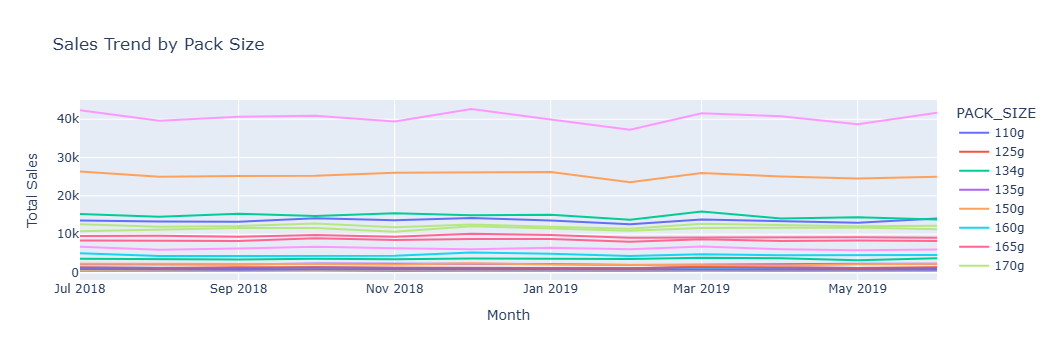

In [104]:
fig = px.line(data_frame= tot_sal_pack,
              x = 'MONTH',
              y = 'TOT_SALES',
              color= 'PACK_SIZE',
              title= 'Sales Trend by Pack Size',
             labels= {'MONTH' : 'Month', 'TOT_SALES' : 'Total Sales'})

fig.show()

In [105]:
df['PRICE'] = df['TOT_SALES'] / df['PROD_QTY']

In [106]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,QUARTER,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt,YOUNG SINGLES/COUPLES,Premium,2018-10,2018Q4,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2,1.45
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3,3.00
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3,4.60


In [107]:
# Checking if the prices of the pack sizes have been the same or different over time
price_pck_size = df.groupby(['MONTH', 'PACK_SIZE'])['PRICE'].mean().reset_index()
price_pck_size['MONTH'] = df['MONTH'].astype(str)
price_pck_size

,MONTH,PACK_SIZE,PRICE
0,2018-10,110g,3.800000
1,2019-05,125g,2.100000
2,2019-05,134g,3.700000
3,2018-08,135g,4.200000
4,2018-08,150g,3.711277
...,...,...,...
247,2019-04,300g,3.918076
248,2019-04,330g,5.700000
249,2019-06,380g,6.224901
250,2018-09,70g,2.400000


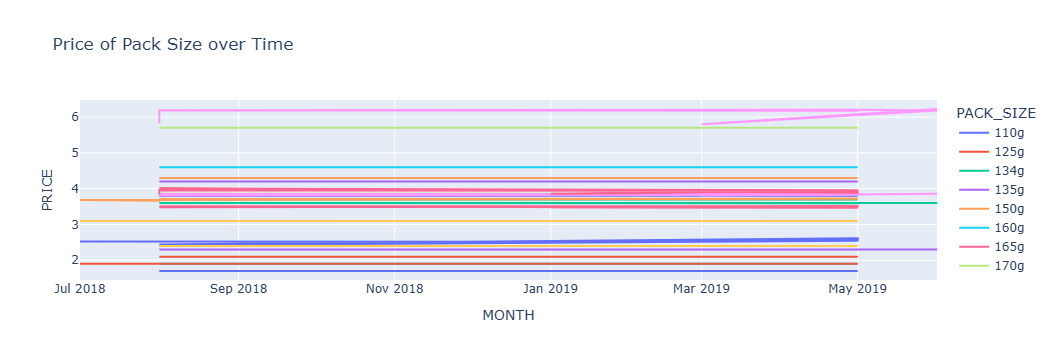

In [108]:
fig = px.line(data_frame= price_pck_size,
              x = 'MONTH',
              y = 'PRICE',
              color= 'PACK_SIZE',
              title = 'Price of Pack Size over Time')

fig.show()

In [109]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER',
       'PRICE'],
      dtype='object')

In [110]:
tot_sal_brand = df.groupby(['MONTH', 'BRAND_NAME'])['TOT_SALES'].sum().reset_index()
tot_sal_brand['MONTH'] = tot_sal_brand['MONTH'].astype(str)
tot_sal_brand

,MONTH,BRAND_NAME,TOT_SALES
0,2018-07,CCs,1675.8
1,2018-07,Cheetos,1527.5
2,2018-07,Cheezels,3026.4
3,2018-07,Cobs Popd,5673.4
4,2018-07,Doritos,20839.3
...,...,...,...
223,2019-06,Thins Chips,5913.6
224,2019-06,Tostitos,7035.6
225,2019-06,Twisties,6845.9
226,2019-06,Tyrrells,4132.8


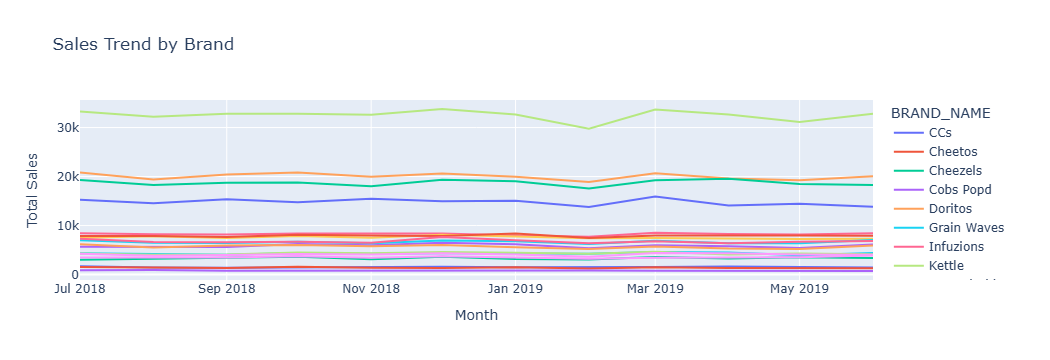

In [111]:
fig = px.line(data_frame= tot_sal_brand,
              x = 'MONTH',
              y = 'TOT_SALES',
              color = 'BRAND_NAME',
              title = 'Sales Trend by Brand',
             labels= {'MONTH' : 'Month', 'TOT_SALES' : 'Total Sales'})
fig.show()

In [112]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER',
       'PRICE'],
      dtype='object')

In [113]:
tot_sal_life = df.groupby(['MONTH', 'LIFESTAGE'])['TOT_SALES'].sum().reset_index()
tot_sal_life['MONTH'] = tot_sal_life['MONTH'].astype(str)
tot_sal_life

,MONTH,LIFESTAGE,TOT_SALES
0,2018-07,MIDAGE SINGLES/COUPLES,15917.4
1,2018-07,NEW FAMILIES,4150.1
2,2018-07,OLDER FAMILIES,30180.2
3,2018-07,OLDER SINGLES/COUPLES,34998.6
4,2018-07,RETIREES,30765.0
...,...,...,...
79,2019-06,OLDER FAMILIES,29018.5
80,2019-06,OLDER SINGLES/COUPLES,33476.9
81,2019-06,RETIREES,29512.6
82,2019-06,YOUNG FAMILIES,26268.9


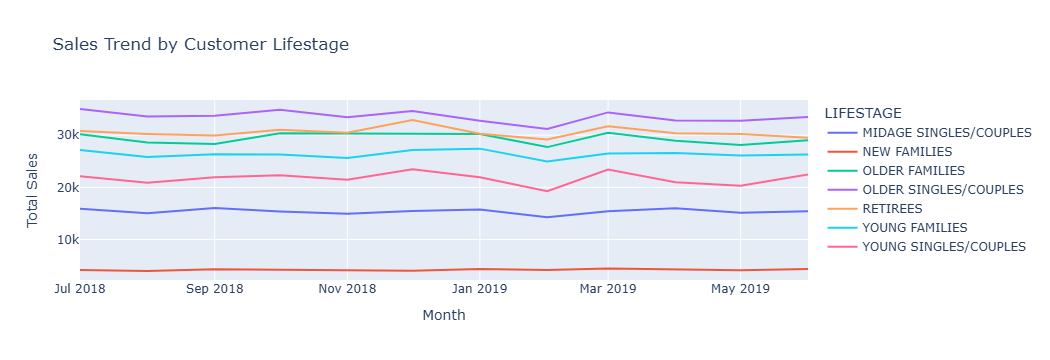

In [114]:
fig = px.line(data_frame= tot_sal_life,
              x = 'MONTH',
              y = 'TOT_SALES',
              color= 'LIFESTAGE',
              title = 'Sales Trend by Customer Lifestage',
             labels= {'MONTH' : 'Month', 'TOT_SALES' : 'Total Sales'})
fig.show()

In [115]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER',
       'PRICE'],
      dtype='object')

In [116]:
tot_sal_prem = df.groupby(['MONTH', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
tot_sal_prem['MONTH'] = tot_sal_prem['MONTH'].astype(str)
tot_sal_prem

,MONTH,PREMIUM_CUSTOMER,TOT_SALES
0,2018-07,Budget,58616.20
1,2018-07,Mainstream,62799.10
2,2018-07,Premium,43860.00
3,2018-08,Budget,55427.70
4,2018-08,Mainstream,61964.65
5,2018-08,Premium,40688.70
6,2018-09,Budget,55855.70
7,2018-09,Mainstream,62137.10
8,2018-09,Premium,42529.20
9,2018-10,Budget,57499.70


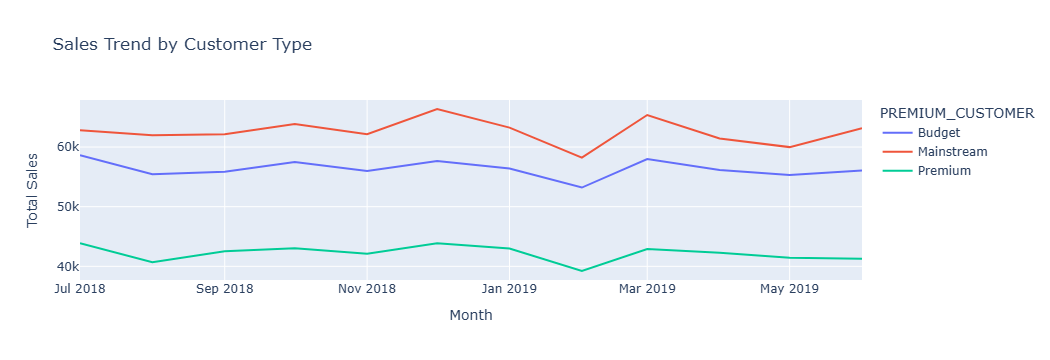

In [117]:
fig = px.line(data_frame= tot_sal_prem,
              x= 'MONTH',
              y= 'TOT_SALES',
              color= 'PREMIUM_CUSTOMER',
              title= 'Sales Trend by Customer Type',
             labels= {'MONTH' : 'Month', 'TOT_SALES' : 'Total Sales'})
fig.show()

In [118]:
df['BRAND_NAME'].unique()

array(['Natural Chip Co', 'CCs', 'Smiths', 'Kettle', 'Old El Paso Salsa',
       'Grain Waves', 'Doritos', 'Twisties', 'Woolworths', 'Thins Chips',
       nan, 'Cheezels', 'Infuzions', 'Red Rock Deli', 'Pringles',
       'Tyrrells', 'Cobs Popd', 'Tostitos', 'Cheetos', 'Sunbites'],
      dtype=object)

In [119]:
not_chip = ['Old El Paso Salsa', 'Woolworths']

df['CATEGORY'] = df['BRAND_NAME'].apply(
    lambda x: 'Not Chips'
    if x in not_chip or pd.isna(x)
    else 'Chips/Snacks')

In [120]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,PRODUCT,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,QUARTER,PRICE,CATEGORY
0,2018-10-17,1,1000,1,5,Natural Chip Co SeaSalt 175g,2,6.0,175g,Natural Chip Co,SeaSalt,YOUNG SINGLES/COUPLES,Premium,2018-10,2018Q4,3.00,Chips/Snacks
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175g,CCs,Nacho Cheese,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2,2.10,Chips/Snacks
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170g,Smiths,Crinkle Cut Chips Chicken,MIDAGE SINGLES/COUPLES,Budget,2019-05,2019Q2,1.45,Chips/Snacks
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175g,Smiths,Chip Thinly S/Cream&Onion,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3,3.00,Chips/Snacks
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150g,Kettle,Tortilla ChpsHny&Jlpno Chili,MIDAGE SINGLES/COUPLES,Budget,2018-08,2018Q3,4.60,Chips/Snacks


In [121]:
df['LYLTY_CARD_NBR'].nunique()

72636

In [122]:
df['PRODUCT'].nunique()

110

In [123]:
df['PROD_NAME'].nunique()

114

In [124]:
names = df['PROD_NAME'].unique()

for name in sorted(names):
    print(name)

Burger Rings 220g
CCs Nacho Cheese 175g
CCs Original 175g
CCs Tasty Cheese 175g
Cheetos Chs & Bacon Balls 190g
Cheetos Puffs 165g
Cheezels Cheese 330g
Cheezels Cheese Box 125g
Cobs Popd Sea Salt Chips 110g
Cobs Popd Sour Crm &Chives Chips 110g
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g
Doritos Cheese Supreme 330g
Doritos Corn Chip Mexican Jalapeno 150g
Doritos Corn Chip Southern Chicken 150g
Doritos Corn Chips Cheese Supreme 170g
Doritos Corn Chips Nacho Cheese 170g
Doritos Corn Chips Original 170g
Doritos Corn Chp Supreme 380g
Doritos Mexicana 170g
Doritos Salsa Medium 300g
Doritos Salsa Mild 300g
French Fries Potato Chips 175g
Grain Waves Plus Btroot & Chilli Jam 180g
Grain Waves Sour Cream&Chives 210g
Grain Waves Sweet Chilli 210g
Infuzions BBQ Rib Prawn Crackers 110g
Infuzions Crn Crnchers Tangy Gcamole 110g
Infuzions Mango Chutny Papadums 70g
Infuzions SourCream&Herbs Veg Strws 110g
Infuzions Thai SweetChili PotatoMix 110g
Kettle Chilli 175g
Kettle Honey Soy Chicken 175g
Kettle Mozz

In [125]:
just_chips = df[~df['BRAND_NAME'].isin(['Old El Paso Salsa', 'Woolworths'])]

In [126]:
just_chips.shape[0]

240752

In [127]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND_NAME',
       'PRODUCT', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'MONTH', 'QUARTER', 'PRICE',
       'CATEGORY'],
      dtype='object')

In [128]:
df.to_excel('Quantium Cleaned Data.xlsx', index = False)